Проведите анализ эффективности контента (иличастотности SEO-запросов) для вашего клиента —строго в рамках темы итогового проекта вашей команды.

Что нужно сделать:
1. Возьмите датасет, который вы создали на практике и сохранили в CSV-файл.
2. Загрузите этот CSV-файл в Python (используйте pandas).
3. Проведите анализ:
    - если вы анализируете контент - посчитайте вовлеченность (лайки, комментарии,репосты), реакции, просмотры, количество контента и т.п. строго в рамках темы итогового проекта вашей команды.
    - если вы анализируете SEO-запросы - оцените частотность поисковых запросов.
4. Постройте понятный график (например, столбчатую диаграмму или линейный график),который наглядно покажет результат вашего анализа.
5. Сделайте краткий вывод по графику.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.5 MB 5.9 MB/s eta 0:00:02
   ----------------------------- ---------- 7.1/9.5 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 12.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------------ --------------- 4.5/7.2 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 20.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ------------

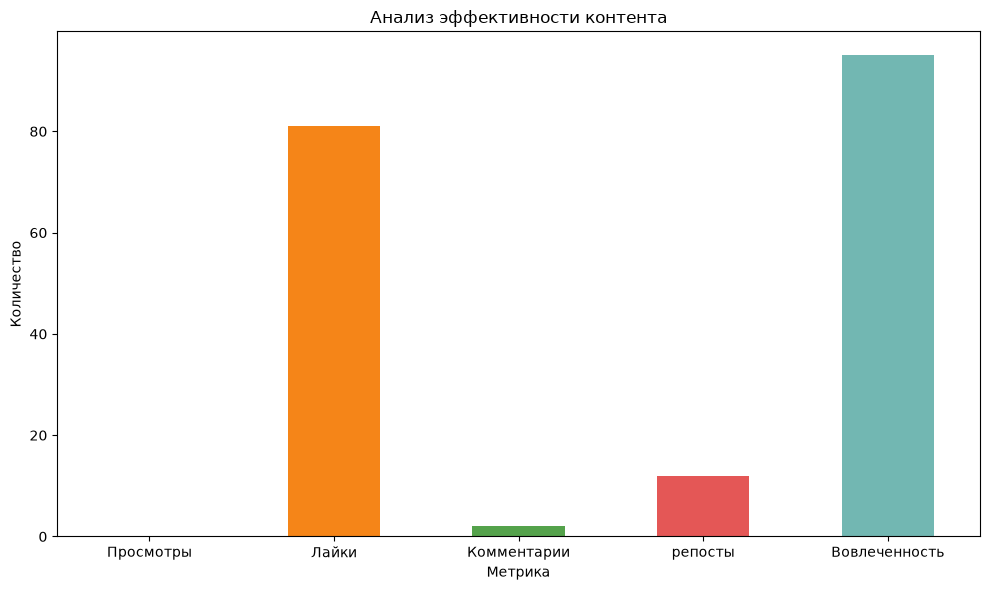

Наибольшее значение у показателя: Вовлеченность.
Это означает, что контент в первую очередь собирает просмотры, а вовлеченность аудитории ниже.
Сводные показатели:
Просмотры         0.0
Лайки            81.0
Комментарии       2.0
репосты          12.0
Вовлеченность    95.0
dtype: float64


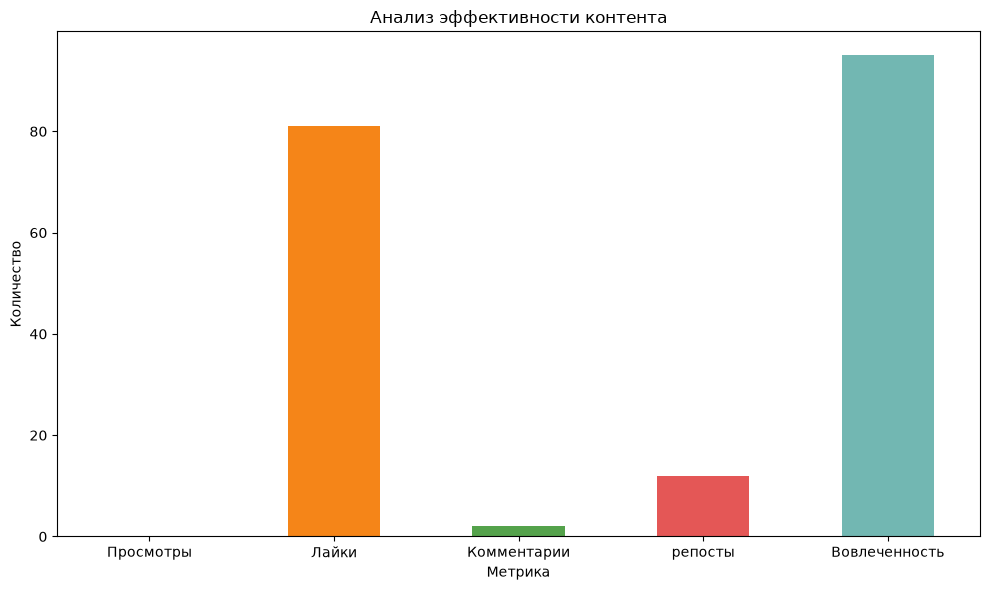

Наибольшее значение у показателя: Вовлеченность.
Это означает, что контент в первую очередь собирает просмотры, а вовлеченность аудитории ниже.


In [1]:
import sys
!{sys.executable} -m pip install pandas
import pandas as pd
import sys
!{sys.executable} -m pip install pandas matplotlib
import matplotlib.pyplot as plt

# Загрузка файла
df = pd.read_csv('01-07-26.csv', sep=';', encoding='utf-8-sig')

# Убираем пустые строки
df = df.dropna(how='all')

# Приводим числовые столбцы к числу
for col in ['Просмотры', 'Лайки', 'Комментарии', 'репосты']:
    df[col] = (
        df[col].astype(str)
        .str.replace(' (за каждое видео)', '', regex=False)
        .str.replace(' ', '', regex=False)
        .replace('', '0')
    )
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Расчет вовлеченности
df['Вовлеченность'] = df['Лайки'] + df['Комментарии'] + df['репосты']

# Сводные данные
summary = df[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].sum()

print("Сводные показатели:")
print(summary)

# График
plt.figure(figsize=(10, 6))
summary[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].plot(
    kind='bar',
    color=['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']
)

plt.title('Анализ эффективности контента')
plt.xlabel('Метрика')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Краткий вывод
max_metric = summary[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].idxmax()
print(f"Наибольшее значение у показателя: {max_metric}.")
print("Это означает, что контент в первую очередь собирает просмотры, а вовлеченность аудитории ниже.")

# Загрузка файла
df = pd.read_csv('01-07-26.csv', sep=';', encoding='utf-8-sig')

# Убираем пустые строки
df = df.dropna(how='all')

# Приводим числовые столбцы к числу
for col in ['Просмотры', 'Лайки', 'Комментарии', 'репосты']:
    df[col] = (
        df[col].astype(str)
        .str.replace(' (за каждое видео)', '', regex=False)
        .str.replace(' ', '', regex=False)
        .replace('', '0')
    )
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Расчет вовлеченности
df['Вовлеченность'] = df['Лайки'] + df['Комментарии'] + df['репосты']

# Сводные данные
summary = df[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].sum()

print("Сводные показатели:")
print(summary)

# График
plt.figure(figsize=(10, 6))
summary[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].plot(
    kind='bar',
    color=['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']
)

plt.title('Анализ эффективности контента')
plt.xlabel('Метрика')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Краткий вывод
max_metric = summary[['Просмотры', 'Лайки', 'Комментарии', 'репосты', 'Вовлеченность']].idxmax()
print(f"Наибольшее значение у показателя: {max_metric}.")
print("Это означает, что контент в первую очередь собирает просмотры, а вовлеченность аудитории ниже.")
